In [1]:
# Pennylane
import pennylane as qml
from pennylane import numpy as np
from scipy.linalg import expm
# Plotting
import matplotlib.pyplot as plt

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pennylane/__init__.py:196: RuntimeWarning: PennyLane is not yet compatible with JAX versions > 0.6.2. You have version 0.8.0 installed. Please downgrade JAX to 0.6.2 to avoid runtime errors using python -m pip install jax~=0.6.0 jaxlib~=0.6.0
  warnings.warn(


# Setting of the main hyper-parameters of the model

In [2]:
n_qubits = 1  # Number of system qubits.
n_shots = 10 ** 6  # Number of quantum measurements.
phase_qubits = 6 # Number of qubits used for phase estimation.
ancilla_qubit = 1 # Number of ancillary qubits used for eigenvalue encoding amplitude
tot_qubits = n_qubits + phase_qubits + ancilla_qubit # Total number of qubits (system + ancillary + QPE qubits).
dim = 2 ** n_qubits  # Dimension of the problem space

In [3]:
# Assume phase_wires and target_wire are defined as in previous cells
phase_wires = range(phase_qubits)  # Phase estimation wires
target_wires = range(phase_qubits, phase_qubits + n_qubits)  # Target wires
ancilla_wires = range(phase_qubits + n_qubits, phase_qubits + n_qubits + ancilla_qubit)  # Ancilla wires

In [44]:
# Input matrix and vector b
A = np.array([[-5, 0.5],[0.5, -4]], dtype=np.complex128)
vector = np.array([0.1, -0.2])

# HHL algorithms

## Unitary Gate of the problem matrix A: $e^{iA}$ 

In [45]:
def apply_unitary(matrix,wires):
    # Define Hermitian matrix A
    # A = np.array([
    #     [1, 0, 0, 1],
    #     [0, 2, 1, 0],
    #     [0, 1, 3, 0],
    #     [1, 0, 0, 4]
    # ], dtype=np.complex128)
    #     A = np.array([[-5, 0.5],
    #            [0.5, -4]], dtype=np.complex128)
    A = -np.array(matrix)
    # Compute the unitary U = exp(iA)
    U = expm(1j * A)
    # Confirm unitarity
    assert np.allclose(U.conj().T @ U, np.eye(2**n_qubits)), "U is not unitary"
    # Apply the unitary operation to the specified wires
    qml.QubitUnitary(U, wires=wires)      

## QPE Circuit

In [46]:
# Define the quantum phase estimation circuit
def qpe_circuit(matrix,phase_wires, target_wire): 
    # Initialize target in eigenstate of U
    # qml.Hadamard(wires=target_wire)

    # Apply Hadamards to phase register
    for w in phase_wires:
        qml.Hadamard(wires=w)

    # Apply controlled-U^{2^k}
    apply_unitary_powers = [2 ** i for i in range(len(phase_wires))]

    for i, power in enumerate(apply_unitary_powers):
        for _ in range(power):
            qml.ctrl(apply_unitary, control=phase_wires[::-1][i])(matrix,wires=target_wire)

    # Apply inverse QFT
    qml.adjoint(qml.QFT)(wires=phase_wires)

## Control-Rotation gate for embedding inverse eigenvalues $\lambda_i \rightarrow \lambda_i^{-1}$

In [47]:
def AQE_fractional_rotation(control_wires, target_wire):
    """Apply controlled RY rotation based on fractional binary interpretation of control qubits."""
    n = len(control_wires)

    for d in range(1, 2**n):  # skip d=0 to avoid divide-by-zero
        # Convert decimal to binary string to run all possible state
        bin_str = f"{d:0{n}b}"
        # Convert binary string to list of bits for controlled rotation
        bit_strings = [int(bit) for bit in bin_str]
        # Compute fractional binary value: d = sum x_j * 2^-j
        fractional_d = sum(int(bit) * 2**-(j+1) for j, bit in enumerate(bin_str))
        # Compute the inverse of the fractional value
        inv = 1 / fractional_d
        # Normalize to [0, 1] range
        inv = inv / (2 ** n)
        # Convert to angle for RY gate, the state |0> amplitude corresponds to inv value
        theta = np.arccos(inv) * 2  # 2*theta for full RY
        # Apply controlled RY rotation on target wire controling on control wires
        qml.ctrl(qml.RY, control=control_wires, control_values=bit_strings)(theta,wires=target_wire)


## HHL Quantum circuit

In [48]:
dev = qml.device("default.qubit", wires=tot_qubits)
@qml.qnode(dev)
def hhl_circuit(matrix, vector):
    # 1. Initialize the target qubit
    # Normalize the input vector
    # vector = np.array([0.03, -0.02])
    norm_vector = vector / np.linalg.norm(vector)
    # Initialize the quantum state to the normalized vector on the target wires
    qml.StatePrep(norm_vector, wires=target_wires)
    # for target_wire in target_wires:
    #     qml.Hadamard(wires=target_wire) # in this example, |b> = U_b |0> = H_0 H_1 ... |0>

    # 2. Apply QPE (Quantum Phase Estimation)
    qpe_circuit(matrix, phase_wires, target_wires)

    # 3. Apply AQE fractional rotation (controlled RY based on phase_wires)
    AQE_fractional_rotation(phase_wires, ancilla_wires)

    # 4. Apply inverse QPE (adjoint of QPE)
    qml.adjoint(qpe_circuit)(matrix, phase_wires, target_wires)

    # Extract the solution vector
    state = qml.state()
    # Return density matrix
    # density = qml.density_matrix(wires=[*target_wires, *ancilla_wires])

    # 5. Measure the target qubit
    probs = qml.probs(wires= [*target_wires,*ancilla_wires])

    return state, probs

## Run HHL algorithm

- Probability of measuring target qubits and ancilla qubit

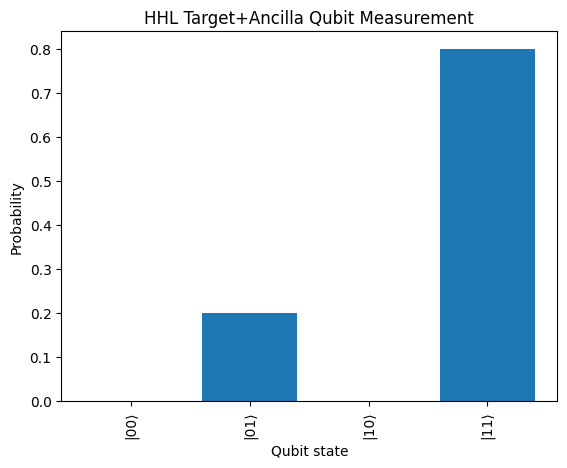

In [49]:
state, probs= hhl_circuit(A, vector)
# Plot the result
plt.bar([f"|{i:0{len(bin(len(probs)-1))-2}b}⟩" for i in range(len(probs))], probs)
plt.xticks(rotation=90)
plt.xlabel("Qubit state")
plt.ylabel("Probability")
plt.title("HHL Target+Ancilla Qubit Measurement")
plt.show()

- Amplitude of quantum states within target qubits and ancilla qubit. We here assumed zero amplitude of phase (for QPE) qubits

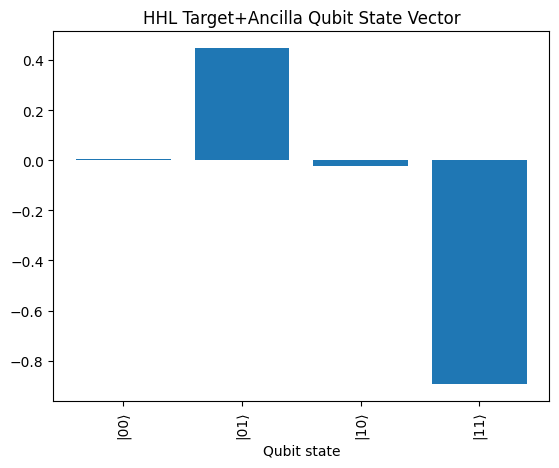

In [50]:
state = state[:(2**(n_qubits+1))] # Keep only target + ancilla part
# Plot the result
plt.bar([f"|{i:0{len(bin(len(state)-1))-2}b}⟩" for i in range(len(state))], state)
plt.xticks(rotation=90)
plt.xlabel("Qubit state")
plt.title("HHL Target+Ancilla Qubit State Vector")
plt.show()

- The diffirence between prob. function and getting from state function is that the getting from the state function we assumed the phase qubits all are zero (approximation, in reality, it doesnt); prob. function measures directly prob. of desired qubits with no information about phase qubits value.

Retain only probabilities where the ancilla qubit (last qubit) is in state |0>

In [51]:
# Get indices where ancilla qubit is 0 (i.e., even indices)
ancil_position = tot_qubits - ancilla_wires[0] - 1  # Assuming ancilla_wires is a list with one element
ancilla_zero_indices = [i for i in range(len(probs)) if (i & 2**ancil_position) == 0]
probs_ancilla0 = probs[ancilla_zero_indices]
print("Probabilities of targer qubits with ancilla qubit in |0>:", probs_ancilla0)
# Normalize the filtered probabilities
probs_ancilla0_normalized = probs_ancilla0 / np.sum(probs_ancilla0)
print("Normalized probabilities:",np.sum(probs_ancilla0_normalized))

Probabilities of targer qubits with ancilla qubit in |0>: [9.65726649e-05 6.56801819e-04]
Normalized probabilities: 1.0


Target qubit probabilities: [0.1281868 0.8718132]


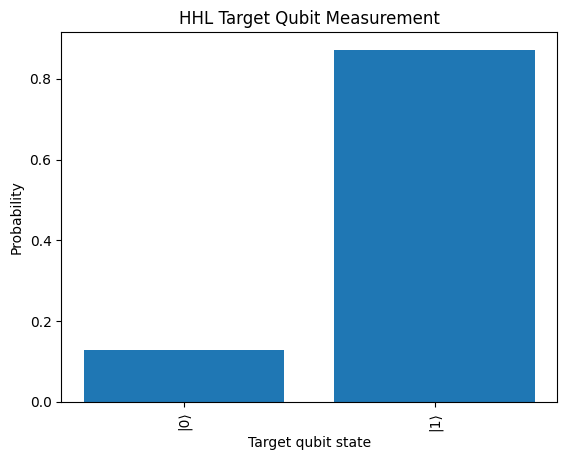

In [52]:
print("Target qubit probabilities:", probs_ancilla0_normalized)
# Plot the result
plt.bar([f"|{i:0{len(bin(len(probs_ancilla0_normalized)-1))-2}b}⟩" for i in range(len(probs_ancilla0_normalized))], probs_ancilla0_normalized)
plt.xticks(rotation=90)
plt.xlabel("Target qubit state")
plt.ylabel("Probability")
plt.title("HHL Target Qubit Measurement")
plt.show()

State vector: [ 0.01479224 -0.04931944]


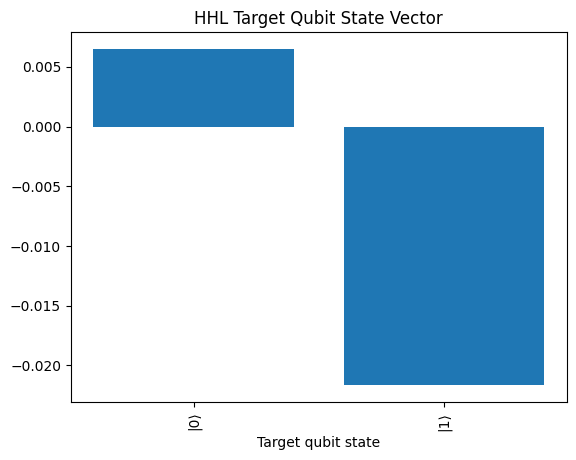

In [53]:
# Get indices where ancilla qubit is 0 (i.e., even indices)
ancil_position = tot_qubits - ancilla_wires[0] - 1  # Assuming ancilla_wires is a list with one element
ancilla_zero_indices = [i for i in range(len(state)) if (i & 2**ancil_position) == 0]
psi_target_ancilla0 = state[ancilla_zero_indices]
print("State vector:", np.real(psi_target_ancilla0)* np.linalg.norm(vector) * 2**(phase_qubits)/(2*np.pi))  # Scale by 2^(n_QPE) to account for normalization in state vector
# Plot the result
plt.bar([f"|{i:0{len(bin(len(psi_target_ancilla0)-1))-2}b}⟩" for i in range(len(psi_target_ancilla0))], psi_target_ancilla0)
plt.xticks(rotation=90)
plt.xlabel("Target qubit state")
plt.title("HHL Target Qubit State Vector")
plt.show()

# Sign extraction from the probablity measured from quantum state

In [313]:
def recover_signs(prob_orig, prob_parity1, prob_parity2, first_sign=1):
    """
    Recover the sign vector of the original state amplitudes given:
      - prob_orig: 1D array-like of original probabilities |c_i|^2 (length L = 2^n)
      - prob_parity1: probabilities from first ancilla parity circuit (length 2*L)
      - prob_parity2: probabilities from second (rotated) ancilla parity circuit (length 2*L)
      - first_sign: sign of the first amplitude (+1 or -1). Default 1.
    Returns:
      - sign_array: np.ndarray of shape (L,) with entries +1 or -1 (the recovered signs)
      - amplitudes: np.ndarray of shape (L,) the signed amplitudes = sign_array * sqrt(prob_orig)
    Notes:
      - This implements the same steps as in the notebook: extract parity couples via slicing [::4],
        build parity arrays by comparing to original probabilities, intertwine them, then reconstruct signs.
      - Assumes prob_parity1 and prob_parity2 follow the same layout produced by the ancilla circuits used above.
    """
    prob_orig = np.asarray(prob_orig)
    p1 = np.asarray(prob_parity1)
    p2 = np.asarray(prob_parity2)

    L = len(prob_orig)
    if L == 0 or (L & (L - 1)) != 0:
        raise ValueError("prob_orig length must be a power of two and > 0.")
    if len(p1) != 2 * L or len(p2) != 2 * L:
        raise ValueError("prob_parity arrays must have length 2 * len(prob_orig).")

    # slice step is 4 as used in the notebook (produces len(orig)/2 parity couples)
    step = 4
    parity_couple_0 = p1[::step] * 2
    parity_couple_1 = p2[::step] * 2

    # build parity arrays comparing each parity couple to the two corresponding original probs
    parity_array_0 = []
    for i, pc in enumerate(parity_couple_0):
        if pc < prob_orig[2 * i] or pc < prob_orig[2 * i + 1]:
            parity_array_0.append(-1)
        else:
            parity_array_0.append(1)

    parity_array_1 = []
    rotated_prob_orig = np.roll(prob_orig, -1) # Move the first element to the last element
    for i, pc in enumerate(parity_couple_1):
        if pc < rotated_prob_orig[2 * i] or pc < rotated_prob_orig[2 * i + 1]:
            parity_array_1.append(-1)
        else:
            parity_array_1.append(1)

    # intertwine parity arrays: a0[0], a1[0], a0[1], a1[1], ...
    a = list(parity_array_0)
    b = list(parity_array_1)
    parity_intertwined = []
    for i in range(max(len(a), len(b))):
        if i < len(a):
            parity_intertwined.append(a[i])
        if i < len(b):
            parity_intertwined.append(b[i])

    if len(parity_intertwined) != L:
        raise ValueError("Intertwined parity length mismatch: expected {}, got {}"
                         .format(L, len(parity_intertwined)))

    # reconstruct signs
    sign_list = []
    s = 1 if first_sign >= 0 else -1
    for i in range(L):
        sign_list.append(int(s))
        s = s * parity_intertwined[i]

    sign_array = np.array(sign_list, dtype=int)
    amplitudes = np.sqrt(prob_orig) * sign_array

    return sign_array, amplitudes

In [314]:
dev = qml.device('default.qubit', wires=tot_qubits+1)
@qml.qnode(dev)

def hhl_sign_detect(matrix, vector):
    # 1. Normalize the input vector
    norm_vector = vector / np.linalg.norm(vector)
    # Initialize the quantum state to the normalized vector on the target wires
    qml.StatePrep(norm_vector, wires=target_wires)
    # for target_wire in target_wires:
    #     qml.Hadamard(wires=target_wire) # in this example, |b> = U_b |0> = H_0 H_1 ... |0>

    # 2. Apply QPE (Quantum Phase Estimation)
    qpe_circuit(matrix, phase_wires, target_wires)

    # 3. Apply AQE fractional rotation (controlled RY based on phase_wires)
    AQE_fractional_rotation(phase_wires, ancilla_wires)

    # 4. Apply inverse QPE (adjoint of QPE)
    qml.adjoint(qpe_circuit)(matrix, phase_wires, target_wires)

    # Swap the two last system qubits (wires total_qubits-2 and total_qubits-1)
    qml.SWAP(wires=[tot_qubits-2, tot_qubits])
    # Hadamard on ancilla (last qubit)
    qml.Hadamard(wires=tot_qubits)

    # Extract the solution vector
    # state = qml.state()

    # 5. Measure the target qubit
    probs = qml.probs(wires= [*target_wires,*ancilla_wires, tot_qubits])
   
    return probs

(<Figure size 5300x800 with 1 Axes>, <Axes: >)

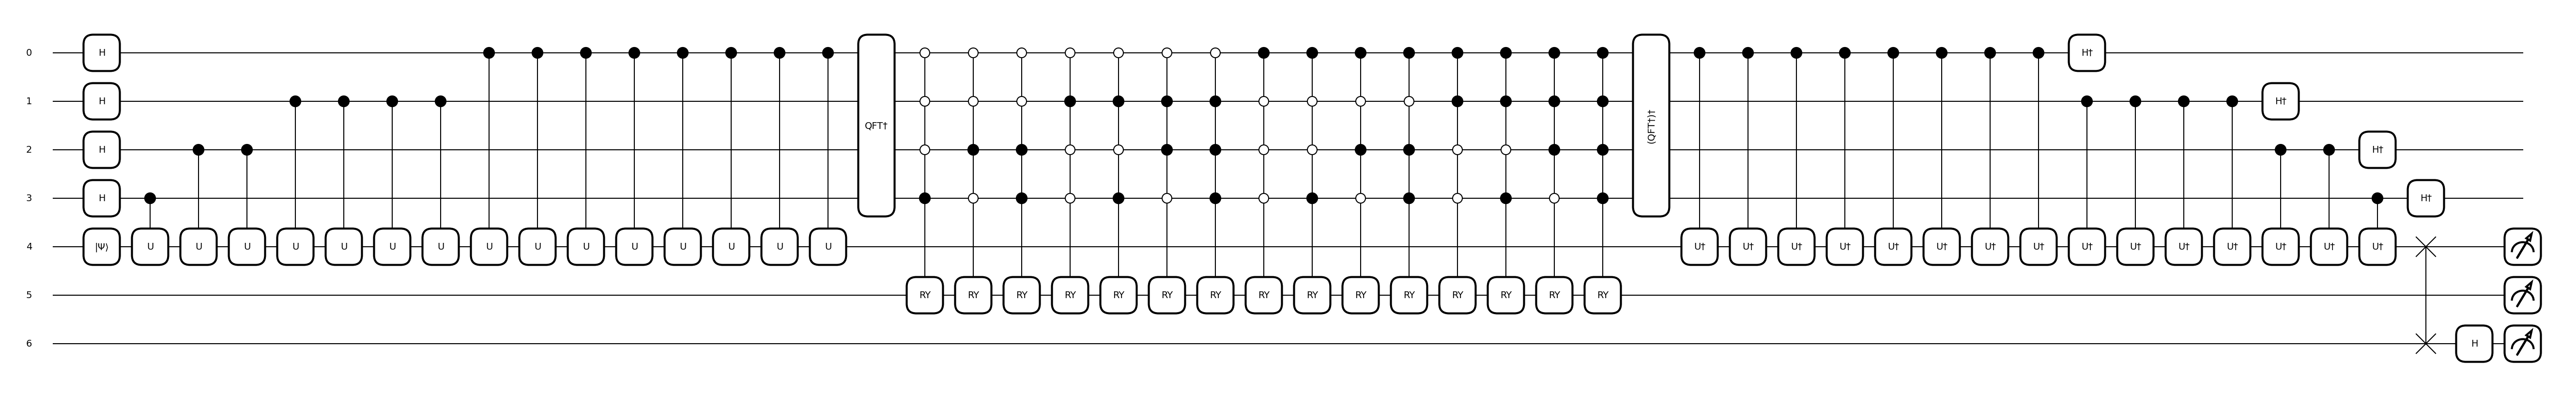

In [316]:
qml.draw_mpl(hhl_sign_detect)(A,vector)

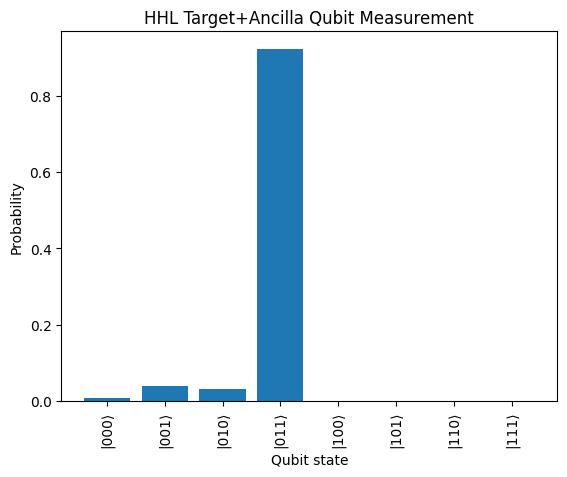

In [ ]:
probs_sign_detect = hhl_sign_detect(A,vector)
# Plot the result
plt.bar([f"|{i:0{len(bin(len(probs_sign_detect)-1))-2}b}⟩" for i in range(len(probs_sign_detect))], probs_sign_detect)
plt.xticks(rotation=90)
plt.xlabel("Qubit state")
plt.ylabel("Probability")
plt.show()

In [ ]:
# Filter probabilities where the ancilla qubit (middle qubit) is in state |0>
ancil_position = 1  # Position of ancilla qubit in the measured wires [target, ancilla, extra]
ancilla_zero_indices = [i for i in range(len(probs_sign_detect)) if (i & 2**ancil_position) == 0]
probs_sign_detect_unrotated = probs_sign_detect[ancilla_zero_indices]
print("Extracted probabilities where ancilla qubit is |0>:", probs_sign_detect_unrotated)

Extracted probabilities where ancilla qubit is |0>: [0.00772782 0.0396726  0.         0.        ]


In [320]:
# Change the order of columns in A, first column becomes last and last column becomes first, in order to change the position in solution vector
A_change = A.copy()
temp = A_change[:, 0].copy()
A_change[:, 0] = A_change[:, -1]
A_change[:, -1] = temp

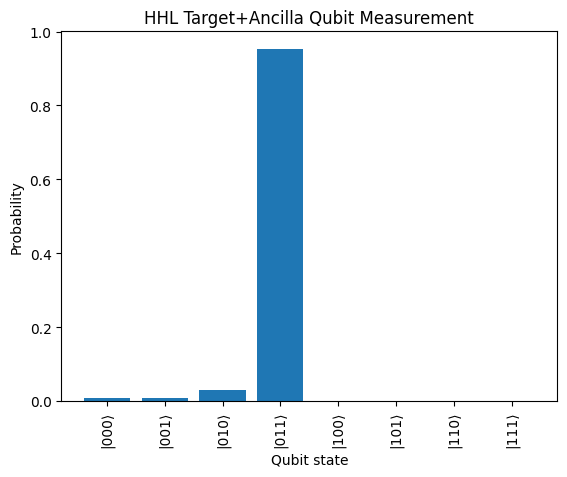

Extracted probabilities where ancilla qubit is |0>: [0.00772782 0.00891072 0.         0.        ]


In [ ]:
probs_sign_detect = hhl_sign_detect(A_change,vector)
# Plot the result
plt.bar([f"|{i:0{len(bin(len(probs_sign_detect)-1))-2}b}⟩" for i in range(len(probs_sign_detect))], probs_sign_detect)
plt.xticks(rotation=90)
plt.xlabel("Qubit state")
plt.ylabel("Probability")
plt.show()
# Filter probabilities where the ancilla qubit (middle qubit, wire 5) is in state |0>
ancil_position = 1  # Position of ancilla qubit in the measured wires [target, ancilla, extra]
ancilla_zero_indices = [i for i in range(len(probs_sign_detect)) if (i & 2**ancil_position) == 0]
probs_sign_detect_rotated = probs_sign_detect[ancilla_zero_indices]
print("Extracted probabilities where ancilla qubit is |0>:", probs_sign_detect_rotated)

In [323]:
restored_vector = recover_signs(probs_ancilla0, probs_sign_detect_unrotated, probs_sign_detect_rotated, first_sign=1)[1]
print("Restored vector:", restored_vector)
print("Original state_vector:", psi_target_ancilla0)

Restored vector: [ 0.19739996 -0.09183505]
Original state_vector: [ 0.1960234 -2.38524478e-17j -0.08258032-3.29597460e-17j]


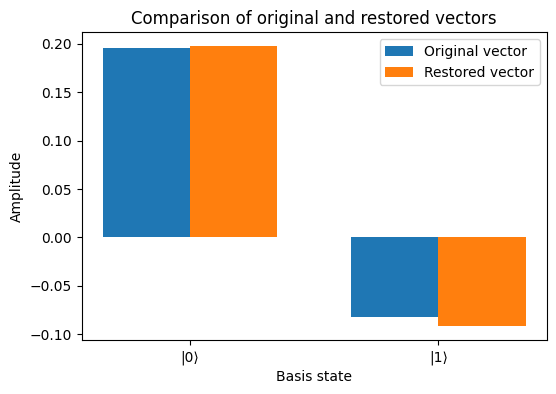

In [324]:
original_vector = np.real(psi_target_ancilla0)
restored_vector = np.real(restored_vector)

labels = [f"|{i:0{len(bin(len(original_vector)-1))-2}b}⟩" for i in range(len(original_vector))]
x = np.arange(len(original_vector))
width = 0.35

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(x - width / 2, original_vector, width, label="Original vector")
ax.bar(x + width / 2, restored_vector, width, label="Restored vector")

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_xlabel("Basis state")
ax.set_ylabel("Amplitude")
ax.set_title("Comparison of original and restored vectors")
ax.legend()
plt.show()

- The bit difference comes from using the prob. function of restored vector and getting from state function of original vector 

In [ ]:
def full_hhl_restore(A, b):
    """
    Full HHL algorithm pipeline to restore the solution vector with signs.
    
    Parameters:
    - A: Input matrix (numpy array).
    - b: Input vector (numpy array).
    
    Returns:
    - restored_vector: The restored solution vector with signs.
    """
    # Normalize the input vector
    norm_b = b / np.linalg.norm(b)
    
    # Step 1: Run HHL circuit to get probabilities
    state, probs = hhl_circuit(A, norm_b)
    
    # Extract probs_ancilla0 (probabilities where ancilla qubit is |0>)
    ancil_position = tot_qubits - ancilla_wires[0] - 1
    ancilla_zero_indices = [i for i in range(len(probs)) if (i & 2**ancil_position) == 0]
    probs_ancilla0 = probs[ancilla_zero_indices]
    
    # Step 2: Run sign detection circuit (unrotated)
    probs_sign_detect = hhl_sign_detect(A, norm_b)
    ancil_position_sign = 1  # Ancilla position in sign detect measurements
    ancilla_zero_indices_sign = [i for i in range(len(probs_sign_detect)) if (i & 2**ancil_position_sign) == 0]
    probs_sign_detect_unrotated = probs_sign_detect[ancilla_zero_indices_sign]
    
    # Step 3: Modify A for rotated sign detection (swap first and last columns)
    A_change = A.copy()
    temp = A_change[:, 0].copy()
    A_change[:, 0] = A_change[:, -1]
    A_change[:, -1] = temp
    
    # Run sign detection circuit (rotated)
    probs_sign_detect_rotated_full = hhl_sign_detect(A_change, norm_b)
    ancilla_zero_indices_rotated = [i for i in range(len(probs_sign_detect_rotated_full)) if (i & 2**ancil_position_sign) == 0]
    probs_sign_detect_rotated = probs_sign_detect_rotated_full[ancilla_zero_indices_rotated]
    
    # Step 4: Recover signs and amplitudes
    signs, amplitudes = recover_signs(probs_ancilla0, probs_sign_detect_unrotated, probs_sign_detect_rotated, first_sign=1)
    
    return amplitudes

## QPE function from Pennylane

In [23]:
def U(wires):
    return qml.RZ(2 * np.pi * 0.5 , wires=wires) # qml.PhaseShift(2 * np.pi / 5, wires=wires)

dev = qml.device("default.qubit", wires=5)
@qml.qnode(dev)
# Another QPE function from Pennylane documentation
def circuit_qpe():
    estimation_wires = [0,1,2,3]
    target_wires = 4
    # initialize to state |1>
    qml.PauliX(wires=4)
    # qml.Hadamard(wires=4)

    for wire in estimation_wires:
        qml.Hadamard(wires=wire)

    qml.ControlledSequence(U(wires=target_wires), control=estimation_wires)

    qml.adjoint(qml.QFT)(wires=estimation_wires)

    return qml.probs(wires=estimation_wires)


In [24]:
probs = circuit_qpe()
print(probs)

[9.49116908e-34 3.21790264e-33 6.19242684e-33 2.64207463e-32
 1.00000000e+00 2.56698383e-32 5.40420435e-33 1.56375685e-33
 2.08281348e-33 2.86729841e-34 8.69953014e-34 7.61240576e-34
 9.37349864e-34 2.03182435e-33 5.80786434e-34 1.42377219e-33]


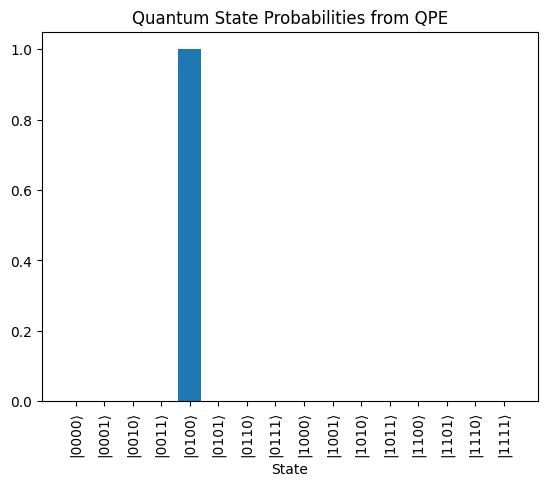

In [26]:
plt.bar([f"|{i:0{len(bin(len(probs)-1))-2}b}⟩" for i in range(len(probs))], probs)
plt.xticks(rotation=90)
plt.xlabel("State")
plt.title("Quantum State Probabilities from QPE")
plt.show()

The order of binary representation in Pennylane is like $\ket{001} = 1$, which is fliping the last qubit (3rd qubit). However, in the reverse binary rep., $\ket{001} = 2^{-3}$

# Comparison of quantum and classical results

## Classical algorithm

Generate the defined matrix A from example above

In [121]:
A_num = np.array([
        [1, 0, 0, 1],
        [0, 2, 1, 0],
        [0, 1, 3, 0],
        [1, 0, 0, 4]
    ], dtype=np.complex128)
b = np.ones(dim) / np.sqrt(dim)

In [54]:
A_num = np.array([[-5, 0.5],
           [0.5, -4]], dtype=np.complex128)
b = vector = np.array([0.1, -0.2]) # np.array([0.03, -0.02])

In [55]:
eigenvalues, eigenvectors = np.linalg.eig(A_num)
print("Eigenvalues:\n", eigenvalues)
print("Eigenvectors:\n", eigenvectors)

Eigenvalues:
 [-5.20710678+0.j -3.79289322+0.j]
Eigenvectors:
 [[ 0.92387953+0.j  0.38268343+0.j]
 [-0.38268343-0.j  0.92387953+0.j]]


In [56]:
print("A = \n", A_num)
print("b = \n", b)

A = 
 [[-5. +0.j  0.5+0.j]
 [ 0.5+0.j -4. +0.j]]
b = 
 [ 0.1 -0.2]


Classical algorithm via np.linalg

In [57]:
# The solution can be computed via a matrix inversion:
A_num = -np.array(A_num)
A_inv = np.linalg.inv(A_num)
x = np.dot(A_inv, b)

In [435]:
# In order to compare x with the quantum state |x>, we normalize and square its elements.
c_probs = (x / np.linalg.norm(x)) ** 2

## Comparison

In [436]:
# Classical result
print("x_n^2 =\n", c_probs)

x_n^2 =
 [0.62613195-0.j 0.37386805+0.j]


In [437]:
# Quantum result
print("|<x|n>|^2=\n", probs_ancilla0_normalized)

|<x|n>|^2=
 [0.61884251 0.38115749]


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/matplotlib/transforms.py:758: ComplexWarning: Casting complex values to real discards the imaginary part
  points = np.asarray(points, float)


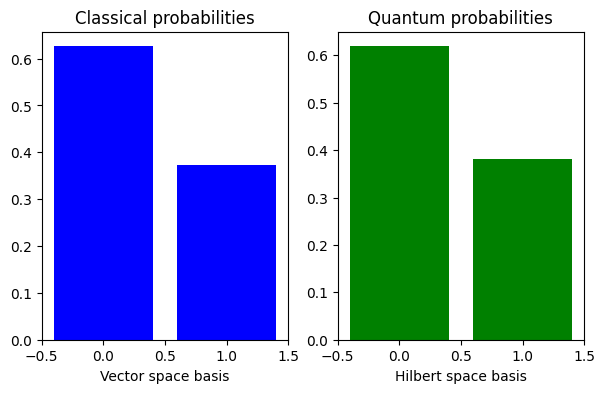

In [438]:
# Graphically visualize both distributions.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, 4))

ax1.bar(np.arange(0, 2 ** n_qubits), c_probs, color="blue")
ax1.set_xlim(-0.5, 2 ** n_qubits - 0.5)
ax1.set_xlabel("Vector space basis")
ax1.set_title("Classical probabilities")

ax2.bar(np.arange(0, 2 ** n_qubits), probs_ancilla0_normalized, color="green")
ax2.set_xlim(-0.5, 2 ** n_qubits - 0.5)
ax2.set_xlabel("Hilbert space basis")
ax2.set_title("Quantum probabilities")

plt.show()

# References

1. Y. Zhou et al., "Quantum computing in power systems" in iEnergy, vol. 1, no. 2, pp. 170-187, June 2022, doi: 10.23919/IEN.2022.0021.
2. Brynjar Sævarsson et al, " Quantum Computing for Power Flow Algorithms: Testing on real Quantum Computers", arXiv:2204.14028
3. Harrow, A. W., Hassidim, A., & Lloyd, S. (2009). Quantum algorithm for linear systems of equations. Physical Review Letters, 103(15), 150502. https://doi.org/10.1103/PhysRevLett.103.150502
4. Ville Bergholm, Josephine Sullivan, et al. (2025, February 26). Solving systems of linear equations via HHL using Qrisp and Catalyst. PennyLane QML Demos. Retrieved from https://pennylane.ai/qml/demos/linear_equations_hhl_qrisp_catalyst